# Data Vis: Plotting Time Series Data
* Notebook 1: Plotting Time Series

## Setup

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Data

In this notebook, we will use a private dataset about (solar) power generation and use of a single family house in Germany. The dataset contains the following columns:
- `timestamp`: The date and time of the measurement. The data is recorded every 1 hour.
- `total_consumption_kw`: The amount of power consumed per hour in kilowatts.
- `from_grid_kw`: The amount of power provided from the grid per hour in kilowatts.
- `from_pv_kw`: The amount of power generated by the solar panels per hour in kilowatts.
- `from_battery_kw`: The amount of power provided by the battery per hour in kilowatts.
- `to_grid_kw`: The amount of power provided to the grid per hour in kilowatts.
- `to_battery_kw`: The amount of power provided to the battery per hour in kilowatts.
- `battery_percent`: The average percentage of battery charge at the time of measurement.
- `battery_kwh`: The average amount of power in the battery at the time of measurement in kilowatt hours.
- various weather data, including temperature, humidity, precipitation, wind speed, and solar radiation (ghi, dni, dhi).

In [2]:
data = pd.read_csv("solar.csv")

In [5]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

In [6]:
data["year"] = data["timestamp"].dt.year
data["month"] = data["timestamp"].dt.month_name()
data["day"] = data["timestamp"].dt.day
data["hour"] = data["timestamp"].dt.hour
data["weekday"] = data["timestamp"].dt.day_name()
data["is_weekend"] = np.where(data["weekday"].isin(["Saturday", "Sunday"]), 1, 0)   

In [7]:
data.set_index("timestamp", inplace=True)

In [21]:
data.max(data["power_output"])

KeyError: 'power_output'

# Line Charts

Line charts are a great way to visualize time series data. They allow us to see trends and patterns over time.

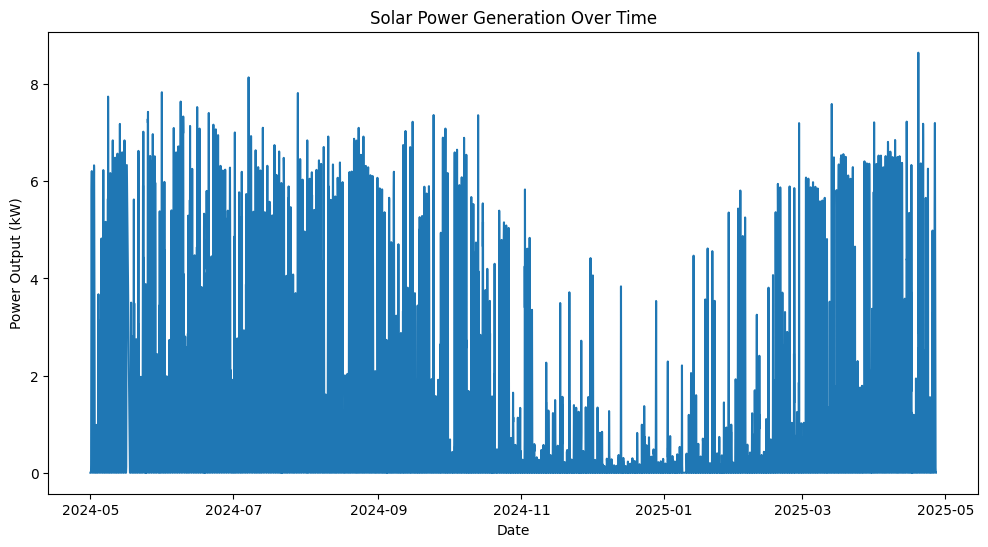

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x=data.index, y="from_pv_kw")
plt.title("Solar Power Generation Over Time")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.show()

The hourly frequency of the data generates a lot of noise. To reduce this noise, we can resample the data to a daily frequency. This will give us a clearer picture of the trends in the data.

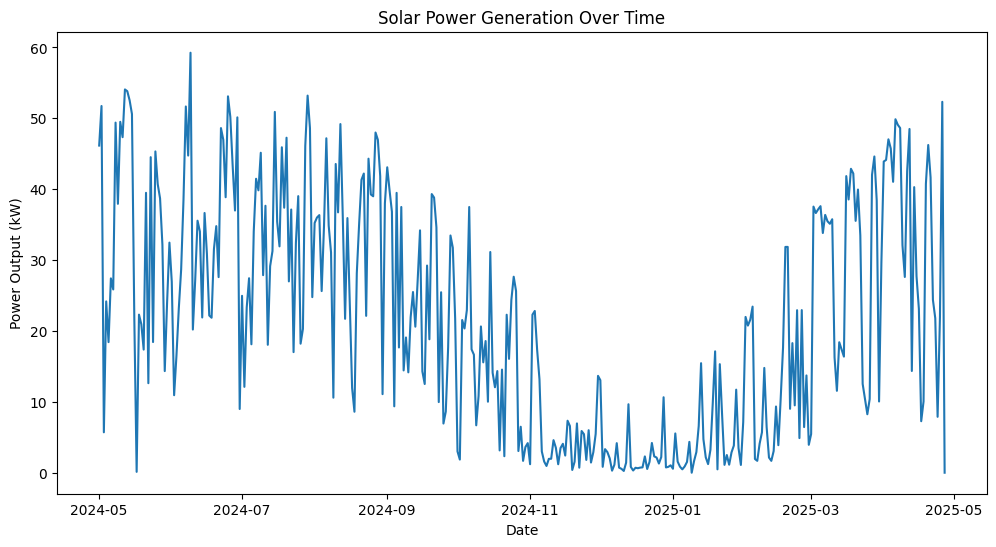

In [10]:
data_daily = data.resample("D").sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_daily, x=data_daily.index, y="from_pv_kw")
plt.title("Solar Power Generation Over Time")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.show()

The daily patterns become more visible when we focus on one week of data.

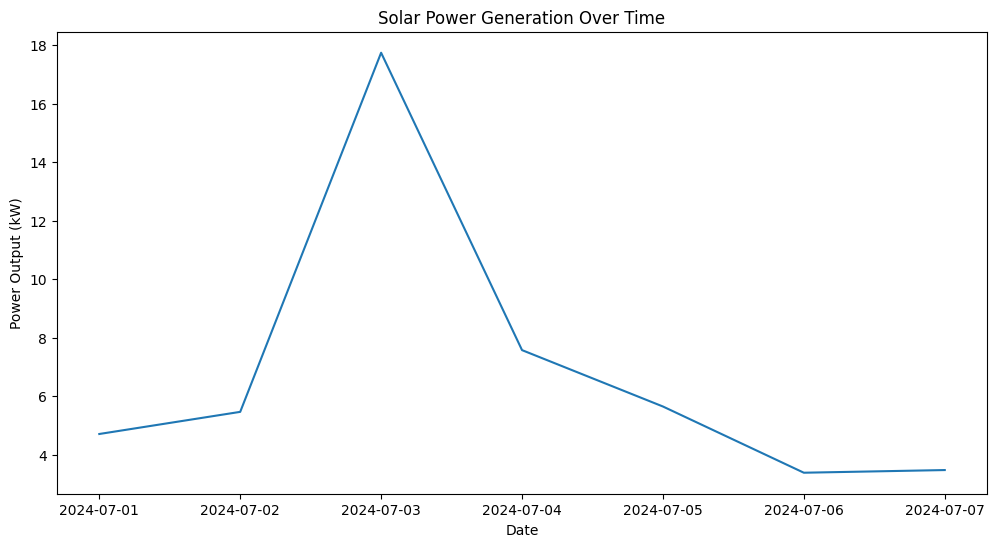

In [31]:
data_1week = data["2024-07-01":"2024-07-07"].resample("D").sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_1week, x=data_1week.index, y="total_consumption_kw")
plt.title("Solar Power Generation Over Time")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.show()

Now it's your turn! Create line charts for other time series in the dataset. You can use the same approach as above to resample the data to a daily frequency and plot the data.

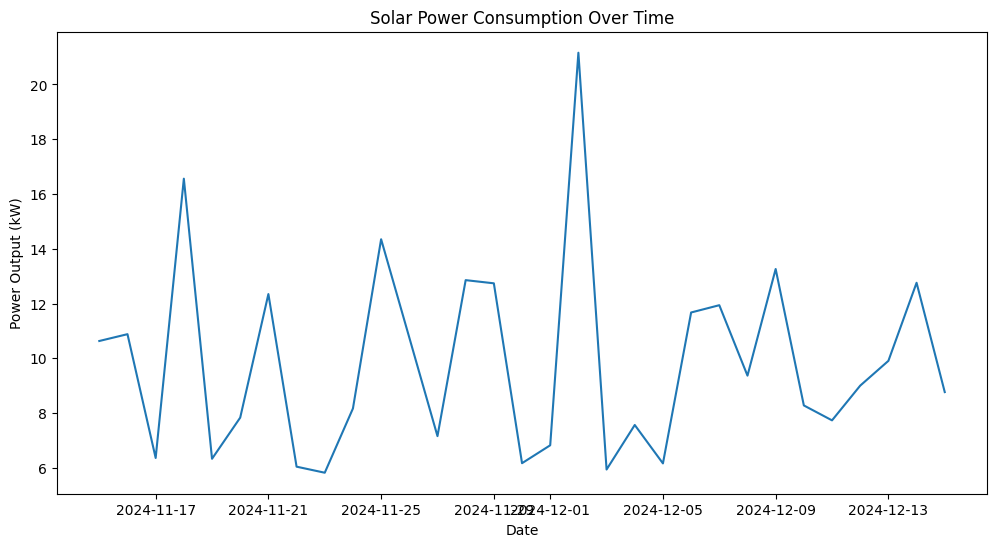

In [ ]:
data_1week = data["2024-11-15":"2024-12-15"].resample("D").sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_1week, x=data_1week.index, y="total_consumption_kw")
plt.title("Solar Power Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.show()

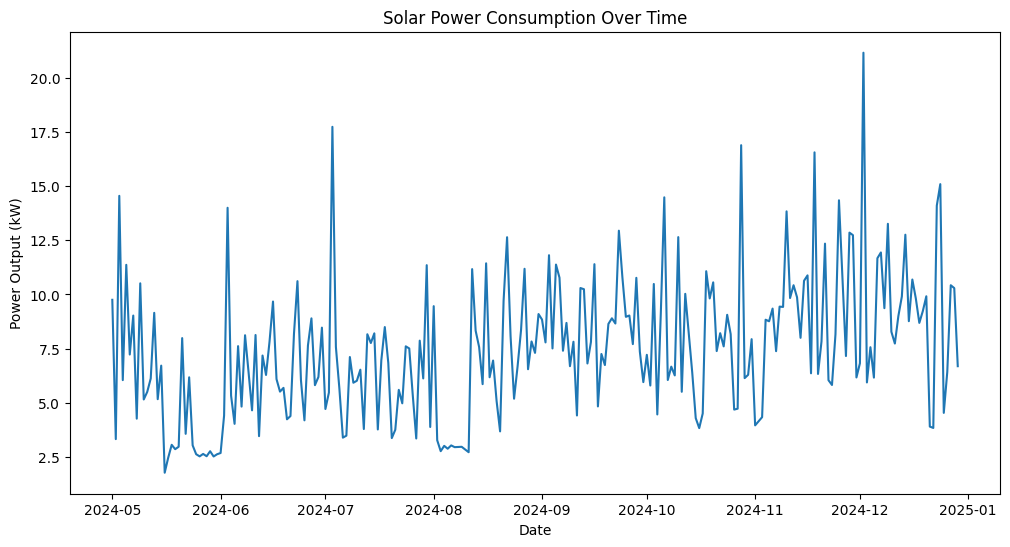

In [35]:
data_1week = data["2024-01-01":"2024-12-29"].resample("D").sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_1week, x=data_1week.index, y="total_consumption_kw")
plt.title("Solar Power Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Power Output (kW)")
plt.show()

# Seasonal Plot

A seasonal plot shows the data for one or more seasons (e.g., month, weekdays) on the same plot. This allows us to see how the data changes over time and how it varies by season.

To do this, we first need to group the data by seasons and arrange the values by weekdays.

In [36]:
data_grouped = data.groupby(["year", "month", "weekday"]).mean().reset_index()
data_grouped["weekday"] = pd.Categorical(data_grouped["weekday"], 
                                          categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], 
                                          ordered=True)

In [37]:
data_grouped

,year,month,weekday,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,...,dni,dhi,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,day,hour,is_weekend
0,2024,August,Friday,0.275467,0.001333,0.863608,0.142267,0.535192,0.194525,0.691658,...,131.594501,84.491667,73.925000,32.250000,38.891667,53.341667,0.120639,16.000000,11.500000,0.0
1,2024,August,Monday,0.286448,0.000104,1.574542,0.073677,1.271896,0.089542,0.831271,...,241.022051,80.052083,45.541667,20.447917,11.270833,20.333333,0.146240,15.500000,11.500000,0.0
2,2024,August,Saturday,0.217333,0.004533,1.451775,0.082825,1.186642,0.134850,0.726642,...,250.019181,71.991667,62.341667,26.283333,23.125000,36.775000,0.149335,17.000000,11.500000,1.0
3,2024,August,Sunday,0.201594,0.000937,1.148260,0.091385,0.892354,0.145969,0.733896,...,165.857516,80.875000,66.250000,41.708333,31.677083,44.041667,0.116889,14.500000,11.500000,1.0
4,2024,August,Thursday,0.322983,0.000450,1.552542,0.139917,1.242425,0.127617,0.746775,...,214.640231,76.100000,75.225000,27.300000,25.825000,54.708333,0.150219,15.000000,11.500000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2025,March,Saturday,0.288042,0.048817,1.076725,0.101883,0.802033,0.136383,0.444425,...,191.350665,47.008333,53.216667,37.208333,9.733333,16.275000,0.088671,15.000000,11.500000,1.0
80,2025,March,Sunday,0.324773,0.010378,1.152143,0.205311,0.888361,0.153689,0.551168,...,223.890335,43.378151,48.899160,22.747899,15.302521,26.957983,0.074031,15.882353,11.571429,1.0
81,2025,March,Thursday,0.256177,0.015771,1.352188,0.122594,1.060115,0.173198,0.537635,...,272.885171,44.583333,30.729167,17.656250,9.583333,13.520833,0.087722,16.500000,11.500000,0.0
82,2025,March,Tuesday,0.346927,0.045115,1.089167,0.196385,0.792229,0.190833,0.442583,...,199.384536,47.531250,52.906250,36.895833,24.562500,25.302083,0.064388,14.500000,11.500000,0.0


Then, we create separate dataframes for each season.

In [38]:
data_grouped_jan = data_grouped[data_grouped["month"] == "January"]
data_grouped_feb = data_grouped[data_grouped["month"] == "February"]
data_grouped_mar = data_grouped[data_grouped["month"] == "March"]
data_grouped_apr = data_grouped[data_grouped["month"] == "April"]
data_grouped_may = data_grouped[data_grouped["month"] == "May"]
data_grouped_jun = data_grouped[data_grouped["month"] == "June"]
data_grouped_jul = data_grouped[data_grouped["month"] == "July"]
data_grouped_aug = data_grouped[data_grouped["month"] == "August"]
data_grouped_sep = data_grouped[data_grouped["month"] == "September"]
data_grouped_oct = data_grouped[data_grouped["month"] == "October"]
data_grouped_nov = data_grouped[data_grouped["month"] == "November"]
data_grouped_dec = data_grouped[data_grouped["month"] == "December"]


In [39]:
data_grouped_jan

,year,month,weekday,total_consumption_kw,from_grid_kw,from_pv_kw,from_battery_kw,to_grid_kw,to_battery_kw,battery_percent,...,dni,dhi,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,day,hour,is_weekend
70,2025,January,Friday,0.433142,0.296983,0.134050,0.089742,0.009808,0.077133,0.078042,...,64.605209,21.091667,61.875000,54.566667,28.116667,17.816667,0.015037,17.0,11.5,0.0
71,2025,January,Monday,0.419771,0.293125,0.215094,0.063500,0.061781,0.088385,0.105250,...,40.329959,20.552083,79.395833,52.802083,30.729167,47.979167,0.024731,16.5,11.5,0.0
72,2025,January,Saturday,0.352583,0.271917,0.153604,0.064833,0.039115,0.097885,0.079812,...,74.244693,16.395833,61.520833,46.718750,33.510417,42.364583,0.013657,14.5,11.5,1.0
73,2025,January,Sunday,0.394594,0.238542,0.281865,0.079875,0.089229,0.115073,0.135823,...,94.087647,12.395833,51.083333,40.583333,40.729167,40.260417,0.017673,15.5,11.5,1.0
74,2025,January,Thursday,0.345458,0.264367,0.074717,0.037058,0.004592,0.024183,0.023958,...,38.811214,15.341667,79.608333,67.508333,53.175000,41.583333,0.009897,16.0,11.5,0.0
75,2025,January,Tuesday,0.378365,0.219604,0.346990,0.127656,0.152146,0.156010,0.145667,...,93.886308,20.583333,75.614583,41.552083,29.145833,37.458333,0.026715,17.5,11.5,0.0
76,2025,January,Wednesday,0.376942,0.249408,0.154958,0.058175,0.011100,0.072225,0.075925,...,39.284796,19.750000,93.058333,63.216667,36.333333,59.058333,0.023850,15.0,11.5,0.0


Finally, we can plot the data using the `lineplot` method. We can see that the electricity consumption is higher on MOndays in the winter months.

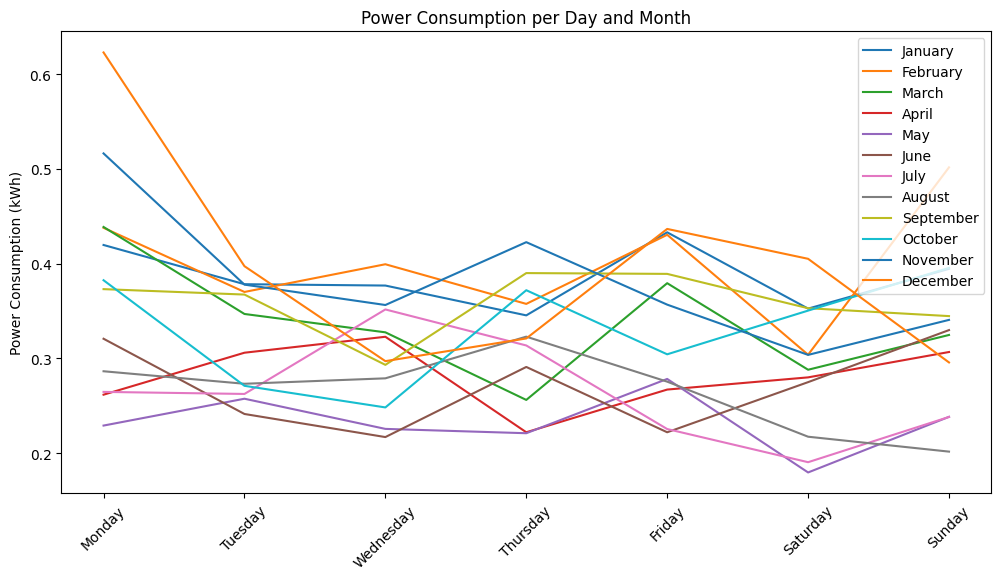

In [40]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data_grouped_jan, x="weekday", y="total_consumption_kw", label="January")
sns.lineplot(data=data_grouped_feb, x="weekday", y="total_consumption_kw", label="February")
sns.lineplot(data=data_grouped_mar, x="weekday", y="total_consumption_kw", label="March")
sns.lineplot(data=data_grouped_apr, x="weekday", y="total_consumption_kw", label="April")
sns.lineplot(data=data_grouped_may, x="weekday", y="total_consumption_kw", label="May")
sns.lineplot(data=data_grouped_jun, x="weekday", y="total_consumption_kw", label="June")
sns.lineplot(data=data_grouped_jul, x="weekday", y="total_consumption_kw", label="July")
sns.lineplot(data=data_grouped_aug, x="weekday", y="total_consumption_kw", label="August")
sns.lineplot(data=data_grouped_sep, x="weekday", y="total_consumption_kw", label="September")
sns.lineplot(data=data_grouped_oct, x="weekday", y="total_consumption_kw", label="October")
sns.lineplot(data=data_grouped_nov, x="weekday", y="total_consumption_kw", label="November")
sns.lineplot(data=data_grouped_dec, x="weekday", y="total_consumption_kw", label="December")
plt.title("Power Consumption per Day and Month")  
plt.xlabel("")
plt.ylabel("Power Consumption (kWh)")
plt.xticks(rotation=45)
plt.legend()
plt.show()
